<a href="https://colab.research.google.com/github/AndresMontesDeOca/NLP_1/blob/main/Desafios/Desafio_4_AndresMontesDeOca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/AndresMontesDeOca/NLP_1/blob/main/Desafios/Desafio_4._AndresMontesDeOca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# **Procesamiento de Lenguaje Natural**
## **Desafio 4, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones.

## 1. Configuración del Entorno

In [ ]:
import os
os.environ["WANDB_API_KEY"] = "XXX"



## 2. Importación de Librerías y W&B Login

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Embedding, Dropout, Bidirectional
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import wandb
from IPython.display import IFrame

try:
    from wandb.keras import WandbMetricsLogger as WandbLogger
except ImportError:
    try:
        from wandb.integration.keras import WandbMetricsLogger as WandbLogger
    except ImportError:
        from wandb.keras import WandbCallback as WandbLogger

# 1. Intentamos obtener la clave usando los Secrets nativos de Google Colab
wandb_key = None
try:
    from google.colab import userdata
    wandb_key = userdata.get('WANDB_API_KEY')
    print("Clave leída exitosamente desde Colab Secrets.")
except Exception:
    pass

# 2. Si no estamos en Colab o falló, hacemos un Fallback al archivo .env local
if not wandb_key:
    try:
        from dotenv import load_dotenv
        load_dotenv('.env')
        load_dotenv('Desafios/.env')
        load_dotenv('../Desafios/.env')
        wandb_key = os.environ.get("WANDB_API_KEY")
        if wandb_key:
            print("Clave leída exitosamente desde .env local.")
    except ImportError:
        pass

# 3. Hacemos el Login definitivo
if wandb_key:
    wandb.login(key=wandb_key, relogin=True)
else:
    print("ERROR FATAL: No se encontró la WANDB_API_KEY ni en Colab Secrets ni en el .env local.")

Clave leída exitosamente desde Colab Secrets.


/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: amontesdeoca1982 (andresmontesdeoca) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 3. Descarga y Preprocesamiento del Dataset

In [ ]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]

MAX_NUM_SENTENCES = 30000 # Subimos a 30K en lugar de 10K el numero de oraciones

np.random.seed(42)
np.random.shuffle(lines)

input_sentences, output_sentences = [], []
for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    input_sentences.append(input_sentence)
    output_sentences.append(output)


output_sentences_inputs = ['<sos> ' + s for s in output_sentences]
output_sentences_targets = [s + ' <eos>' for s in output_sentences]

### 3.1 Tokenizamos

In [ ]:
MAX_VOCAB_SIZE = 10000 # Al tener mas oraciones, tambien subimos el tamano del vocabulario

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)
output_tokenizer.fit_on_texts(output_sentences_inputs + output_sentences_targets)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
output_target_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_targets)
word2idx_outputs = output_tokenizer.word_index

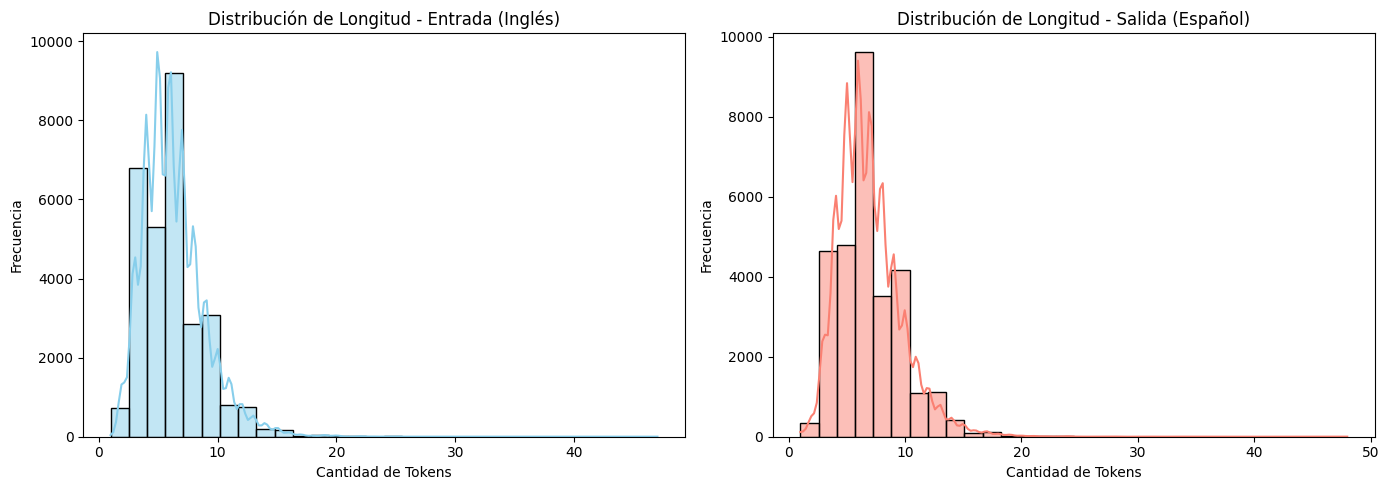

Longitud máxima de entrada: 47
Percentil 97 entrada: 12.0
Percentil 98 entrada: 13.0
Percentil 99 entrada: 14.0
------------------------------
Longitud máxima de salida: 48
Percentil 97 salida: 13.0
Percentil 98 salida: 14.0
Percentil 99 salida: 15.0


In [ ]:
# Calculamos las longitudes de cada secuencia
input_lengths = [len(seq) for seq in input_integer_seq]
output_lengths = [len(seq) for seq in output_input_integer_seq]

# Creamos los gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma para secuencias de entrada
sns.histplot(input_lengths, bins=30, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Distribución de Longitud - Entrada (Inglés)')
axes[0].set_xlabel('Cantidad de Tokens')
axes[0].set_ylabel('Frecuencia')

# Histograma para secuencias de salida
sns.histplot(output_lengths, bins=30, ax=axes[1], color='salmon', kde=True)
axes[1].set_title('Distribución de Longitud - Salida (Español)')
axes[1].set_xlabel('Cantidad de Tokens')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Imprimimos algunos estadísticos útiles
print(f"Longitud máxima de entrada: {max(input_lengths)}")
print(f"Percentil 97 entrada: {np.percentile(input_lengths, 97)}")
print(f"Percentil 98 entrada: {np.percentile(input_lengths, 98)}")
print(f"Percentil 99 entrada: {np.percentile(input_lengths, 99)}")
print("-" * 30)
print(f"Longitud máxima de salida: {max(output_lengths)}")
print(f"Percentil 97 salida: {np.percentile(output_lengths, 97)}")
print(f"Percentil 98 salida: {np.percentile(output_lengths, 98)}")
print(f"Percentil 99 salida: {np.percentile(output_lengths, 99)}")


In [ ]:
# Seteamos las cotas al precentil 99
max_input_len = 14
max_out_len = 15

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")

Vocabulario EN: 8088 | ES: 13858
max_input_len=14  max_out_len=15


### 3.2 Padding

In [ ]:
encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_target_integer_seq, maxlen=max_out_len, padding='post')
num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

print(encoder_input_sequences[0])
print(decoder_input_sequences[0])
print(decoder_output_sequences[0])

[   0    0    0    0    0    0    0    0    0    0    0    0   51 1177]
[   1  466 3108    0    0    0    0    0    0    0    0    0    0    0
    0]
[ 466 3108    2    0    0    0    0    0    0    0    0    0    0    0
    0]


### 3.3 Funcion de armado de batches  y OHE

In [ ]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):
    n = len(enc_seqs)
    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

### 3.4 Split

In [ ]:
BATCH_SIZE = 64
val_split = 0.15
split_idx = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

## 4. Carga de Embeddings Pre-entrenados (GloVe)

In [ ]:
_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

if os.path.exists(_PKL_PATH) and not _is_valid_pickle(_PKL_PATH):
    os.remove(_PKL_PATH)

if not os.path.exists(_PKL_PATH):
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=True)
    except ImportError:
        os.system(f"curl -L -o {_PKL_PATH} 'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")

max_bytes = 2**28 - 1
raw = bytearray()
sz = os.path.getsize(_PKL_PATH)
with open(_PKL_PATH, 'rb') as f:
    for _ in range(0, sz, max_bytes):
        raw += f.read(max_bytes)
glove_embeddings = pickle.loads(raw)

idx_array = np.arange(glove_embeddings.shape[0])
glove_word2idx = dict(zip(glove_embeddings['word'], idx_array))

EMBED_DIM = 50
nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs))
embedding_matrix = np.zeros((nb_words, EMBED_DIM))

for word, i in word2idx_inputs.items():
    if i < nb_words:
        idx_glove = glove_word2idx.get(word, -1)
        if idx_glove != -1:
            embedding_matrix[i] = glove_embeddings[idx_glove]['embedding']


In [ ]:
# Calculamos cuántas palabras de nuestro vocabulario fueron encontradas en GloVe
# (las que no se encontraron quedaron como vectores de ceros)
words_found = np.sum(np.any(embedding_matrix != 0, axis=1))

print("--- Información de Embeddings GloVe ---")
print(f"Dimensión de los embeddings (EMBED_DIM): {EMBED_DIM}")
print(f"Tamaño total del vocabulario de entrada (Inglés): {len(word2idx_inputs)}")
print(f"Límite del vocabulario (MAX_VOCAB_SIZE): {MAX_VOCAB_SIZE}")
print(f"Forma de la matriz de embeddings: {embedding_matrix.shape}")
print(f"Palabras encontradas en GloVe: {words_found} de {nb_words} ({(words_found/nb_words)*100:.2f}%)")


--- Información de Embeddings GloVe ---
Dimensión de los embeddings (EMBED_DIM): 50
Tamaño total del vocabulario de entrada (Inglés): 8088
Límite del vocabulario (MAX_VOCAB_SIZE): 10000
Forma de la matriz de embeddings: (8088, 50)
Palabras encontradas en GloVe: 7709 de 8088 (95.31%)


## 5. Fucion de Arquitectura del Modelo

In [ ]:
def build_seq2seq_model(n_units=256, dropout_rate=0.3, rnn_type='lstm', bidirectional=False):
    enc_inputs = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(dropout_rate, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    if rnn_type == 'gru':
        enc_rnn_layer = GRU(n_units, return_state=True, name='encoder_gru')
        if bidirectional:
            enc_rnn_layer = Bidirectional(enc_rnn_layer, name='encoder_bilstm')
            enc_out, forward_h, backward_h = enc_rnn_layer(enc_emb)
            state_h = tf.keras.layers.Concatenate()([forward_h, backward_h])
            enc_states = [state_h]
            dec_units = n_units * 2
        else:
            _, state_h = enc_rnn_layer(enc_emb)
            enc_states = [state_h]
            dec_units = n_units
    else:
        enc_rnn_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
        if bidirectional:
            enc_rnn_layer = Bidirectional(enc_rnn_layer, name='encoder_bilstm')
            enc_out, forward_h, forward_c, backward_h, backward_c = enc_rnn_layer(enc_emb)
            state_h = tf.keras.layers.Concatenate()([forward_h, backward_h])
            state_c = tf.keras.layers.Concatenate()([forward_c, backward_c])
            enc_states = [state_h, state_c]
            dec_units = n_units * 2
        else:
            _, state_h, state_c = enc_rnn_layer(enc_emb)
            enc_states = [state_h, state_c]
            dec_units = n_units

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=dec_units,
        name='decoder_embedding'
    )
    dec_emb = Dropout(dropout_rate, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    if rnn_type == 'gru':
        dec_rnn_layer = GRU(dec_units, return_sequences=True, return_state=True, name='decoder_gru')
        dec_out, _ = dec_rnn_layer(dec_emb, initial_state=enc_states)
    else:
        dec_rnn_layer = LSTM(dec_units, return_sequences=True, return_state=True, name='decoder_lstm')
        dec_out, _, _ = dec_rnn_layer(dec_emb, initial_state=enc_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_outputs = dec_dense_layer(dec_out)

    model = Model([enc_inputs, dec_inputs], dec_outputs)

    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )

    return model, enc_inputs, enc_states, enc_emb_layer, enc_rnn_layer, dec_inputs, dec_emb_layer, dec_rnn_layer, dec_dense_layer

## 6. Funciones de Inferencia


In [ ]:
# --- Funciones de Inferencia ---
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_rnn_layer, rnn_type='lstm', bidirectional=False):
    enc_emb = enc_emb_layer(enc_inputs)
    if rnn_type == 'gru':
        if bidirectional:
            enc_out, forward_h, backward_h = enc_rnn_layer(enc_emb)
            state_h = tf.keras.layers.Concatenate()([forward_h, backward_h])
            return Model(enc_inputs, [state_h])
        else:
            _, state_h = enc_rnn_layer(enc_emb)
            return Model(enc_inputs, [state_h])
    else:
        if bidirectional:
            enc_out, forward_h, forward_c, backward_h, backward_c = enc_rnn_layer(enc_emb)
            state_h = tf.keras.layers.Concatenate()([forward_h, backward_h])
            state_c = tf.keras.layers.Concatenate()([forward_c, backward_c])
            return Model(enc_inputs, [state_h, state_c])
        else:
            _, state_h, state_c = enc_rnn_layer(enc_emb)
            return Model(enc_inputs, [state_h, state_c])

def build_decoder_inference(dec_emb_layer, dec_rnn_layer, dec_dense_layer, dec_units, rnn_type='lstm'):
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_emb_single = dec_emb_layer(dec_input_single)

    if rnn_type == 'gru':
        dec_state_h_in = Input(shape=(dec_units,), name='dec_state_h')
        dec_out, h_out = dec_rnn_layer(dec_emb_single, initial_state=[dec_state_h_in])
        dec_out = dec_dense_layer(dec_out)
        return Model([dec_input_single, dec_state_h_in], [dec_out, h_out])
    else:
        dec_state_h_in = Input(shape=(dec_units,), name='dec_state_h')
        dec_state_c_in = Input(shape=(dec_units,), name='dec_state_c')
        dec_out, h_out, c_out = dec_rnn_layer(dec_emb_single, initial_state=[dec_state_h_in, dec_state_c_in])
        dec_out = dec_dense_layer(dec_out)
        return Model([dec_input_single, dec_state_h_in, dec_state_c_in], [dec_out, h_out, c_out])

def translate_sentence(input_seq, encoder_model, decoder_model, rnn_type='lstm'):
    states = encoder_model.predict(input_seq, verbose=0)
    if rnn_type == 'gru':
        h = states
    else:
        h, c = states

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    idx2word_target = {v: k for k, v in word2idx_outputs.items()}
    output_sentence = []

    for _ in range(max_out_len):
        if rnn_type == 'gru':
            output_tokens, h = decoder_model.predict([target_seq, h], verbose=0)
        else:
            output_tokens, h, c = decoder_model.predict([target_seq, h, c], verbose=0)

        idx = np.argmax(output_tokens[0, 0, :])
        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target.get(idx, ''))
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)

def translate(text, encoder_model, decoder_model, rnn_type='lstm'):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq, encoder_model, decoder_model, rnn_type)




### 7. Funcion de Experimentacion

In [ ]:
def run_experiment(exp_name, n_units=256, rnn_type='lstm', bidirectional=False):
    os.environ["WANDB_SILENT"] = "true"

    wandb_key = os.environ.get("WANDB_API_KEY")
    if wandb_key:
        wandb.login(key=wandb_key, relogin=True)
    else:
        wandb.login(anonymous="allow")

    run = wandb.init(
        project="Desafio4_NLP_Traductor",
        name=exp_name,
        config={
            "learning_rate": 5e-4,
            "epochs": 100,  # Aumentamos el máximo de epochs a 100
            "batch_size": BATCH_SIZE,
            "n_units": n_units,
            "rnn_type": rnn_type,
            "bidirectional": bidirectional,
            "dataset_size": MAX_NUM_SENTENCES
        },
        reinit=True
    )

    model, *components = build_seq2seq_model(n_units=n_units, rnn_type=rnn_type, bidirectional=bidirectional)

    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
    # Usamos EarlyStopping para frenar si hay overfitting, aumentamos un poco la paciencia a 5
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

    try:
        wandb_logger = WandbLogger()
        callbacks = [lr_scheduler, early_stop, wandb_logger]
    except NameError:
        callbacks = [lr_scheduler, early_stop]

    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=wandb.config.epochs,
        callbacks=callbacks,
        verbose=1
    )
    wandb.finish()

    # --- Evaluación Automática del Modelo Recién Entrenado ---
    print(f"\n=============================================")
    print(f"  Resultados de Inferencia: {exp_name}")
    print(f"=============================================")

    enc_in, enc_states, enc_emb, enc_rnn, dec_in, dec_emb, dec_rnn, dec_dense = components
    dec_units = n_units * 2 if bidirectional else n_units

    encoder_model = build_encoder_inference(enc_in, enc_emb, enc_rnn, rnn_type=rnn_type, bidirectional=bidirectional)
    decoder_model = build_decoder_inference(dec_emb, dec_rnn, dec_dense, dec_units=dec_units, rnn_type=rnn_type)

    frases_prueba = [
        "I want to eat an apple.",
        "She is reading a very good book.",
        "What time does the train leave?",
        "We went to the beach yesterday.",
        "The weather is beautiful today, isn't it?"
    ]

    for s in frases_prueba:
        print(f"EN: {s}")
        print(f"ES: {translate(s, encoder_model, decoder_model, rnn_type=rnn_type)}\n")

    return model, components


## 8. Ejecucion de Experimentos

### 8.1 Experimento 1: LSTM (256 unidades)

In [ ]:
model_1, comp_1 = run_experiment("Exp1_LSTM_256", n_units=256, rnn_type='lstm', bidirectional=False)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 1/100
    397/Unknown 17s 31ms/step - accuracy: 0.5515 - loss: 4.1821

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


399/399 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.5920 - loss: 3.1191 - val_accuracy: 0.6251 - val_loss: 2.5673 - learning_rate: 5.0000e-04
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6273 - loss: 2.5476 - val_accuracy: 0.6416 - val_loss: 2.3858 - learning_rate: 5.0000e-04
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6440 - loss: 2.3623 - val_accuracy: 0.6576 - val_loss: 2.2306 - learning_rate: 5.0000e-04
Epoch 4/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6576 - loss: 2.2039 - val_accuracy: 0.6691 - val_loss: 2.0996 - learning_rate: 5.0000e-04
Epoch 5/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6697 - loss: 2.0593 - val_accuracy: 0.6798 - val_loss: 1.9871 - learning_rate: 5.0000e-04
Epoch 6/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6802 - loss: 1.9353 - val_accuracy: 0.6882 - val_loss: 1.8990 - learning_rate: 5.0000e-04
Epoch 7/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - a

epoch/accuracy,▁▂▂▃▃▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇▇██████████████████
epoch/epoch,▁▁▁▁▁▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
epoch/learning_rate,█████████████████████▄▄▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▃▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇██████████████████████
epoch/val_loss,█▇▅▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,0.85391
epoch/epoch,57
epoch/learning_rate,1e-05
epoch/loss,0.6305
epoch/val_accuracy,0.75716



  Resultados de Inferencia: Exp1_LSTM_256
EN: I want to eat an apple.
ES: quiero comprar una manzana

EN: She is reading a very good book.
ES: ella está escribiendo una buena idea

EN: What time does the train leave?
ES: a qué hora llega el tren

EN: We went to the beach yesterday.
ES: fuimos al parque ayer

EN: The weather is beautiful today, isn't it?
ES: el verano es muy lejos de la mía



### 8.2 Experimento 2: LSTM (512 unidades)

In [ ]:
model_2, comp_2 = run_experiment("Exp2_LSTM_512", n_units=512, rnn_type='lstm', bidirectional=False)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Epoch 1/100
    399/Unknown 21s 47ms/step - accuracy: 0.5735 - loss: 3.6472

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


399/399 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.6081 - loss: 2.8928 - val_accuracy: 0.6362 - val_loss: 2.4671 - learning_rate: 5.0000e-04
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.6414 - loss: 2.3976 - val_accuracy: 0.6587 - val_loss: 2.2081 - learning_rate: 5.0000e-04
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.6611 - loss: 2.1476 - val_accuracy: 0.6750 - val_loss: 2.0184 - learning_rate: 5.0000e-04
Epoch 4/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.6779 - loss: 1.9477 - val_accuracy: 0.6899 - val_loss: 1.8732 - learning_rate: 5.0000e-04
Epoch 5/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.6923 - loss: 1.7777 - val_accuracy: 0.7006 - val_loss: 1.7609 - learning_rate: 5.0000e-04
Epoch 6/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.7052 - loss: 1.6306 - val_accuracy: 0.7099 - val_loss: 1.6697 - learning_rate: 5.0000e-04
Epoch 7/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - a

epoch/accuracy,▁▂▂▃▃▃▄▄▄▄▅▅▅▆▆▆▇▇▇▇▇███████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
epoch/learning_rate,██████████████████▄▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▇▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▃▄▄▅▅▆▆▆▇▇▇▇▇▇████████████████████████
epoch/val_loss,█▆▅▄▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,0.90242
epoch/epoch,42
epoch/learning_rate,1e-05
epoch/loss,0.42135
epoch/val_accuracy,0.7661



  Resultados de Inferencia: Exp2_LSTM_512
EN: I want to eat an apple.
ES: quiero comprar un

EN: She is reading a very good book.
ES: ella está escribiendo una buena novela

EN: What time does the train leave?
ES: a qué hora empieza el tren

EN: We went to the beach yesterday.
ES: fuimos al parque el verano

EN: The weather is beautiful today, isn't it?
ES: el sol es demasiado bonita para la mía



### 8.3 Experimento 3: GRU (256 unidades)

In [ ]:
model_3, comp_3 = run_experiment("Exp3_GRU_256", n_units=256, rnn_type='gru', bidirectional=False)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Epoch 1/100
    397/Unknown 14s 32ms/step - accuracy: 0.5634 - loss: 4.2028

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


399/399 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.5989 - loss: 3.1121 - val_accuracy: 0.6233 - val_loss: 2.5336 - learning_rate: 5.0000e-04
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.6276 - loss: 2.4881 - val_accuracy: 0.6441 - val_loss: 2.3131 - learning_rate: 5.0000e-04
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.6502 - loss: 2.2467 - val_accuracy: 0.6628 - val_loss: 2.1180 - learning_rate: 5.0000e-04
Epoch 4/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.6668 - loss: 2.0533 - val_accuracy: 0.6773 - val_loss: 1.9777 - learning_rate: 5.0000e-04
Epoch 5/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.6797 - loss: 1.8966 - val_accuracy: 0.6868 - val_loss: 1.8679 - learning_rate: 5.0000e-04
Epoch 6/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.6902 - loss: 1.7652 - val_accuracy: 0.6945 - val_loss: 1.7814 - learning_rate: 5.0000e-04
Epoch 7/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - a

epoch/accuracy,▁▂▂▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇██████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
epoch/learning_rate,███████████████████▄▄▄▄▃▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▃▄▄▅▆▆▆▆▇▇▇▇▇▇█████████████████████████
epoch/val_loss,█▇▆▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,0.86458
epoch/epoch,51
epoch/learning_rate,1e-05
epoch/loss,0.58952
epoch/val_accuracy,0.75646



  Resultados de Inferencia: Exp3_GRU_256
EN: I want to eat an apple.
ES: quiero comprar un diccionario

EN: She is reading a very good book.
ES: ella está escribiendo una buena libro

EN: What time does the train leave?
ES: a qué hora empieza el tren

EN: We went to the beach yesterday.
ES: ayer fueron al parque

EN: The weather is beautiful today, isn't it?
ES: el verano es la mejor que no se puede ver



### 8.4 Experimento 4: Bidirectional LSTM (256 unidades)

In [ ]:
model_4, comp_4 = run_experiment("Exp4_BiLSTM_256", n_units=256, rnn_type='lstm', bidirectional=True)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Epoch 1/100
    398/Unknown 21s 47ms/step - accuracy: 0.5757 - loss: 3.6643

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


399/399 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.6099 - loss: 2.8903 - val_accuracy: 0.6377 - val_loss: 2.4507 - learning_rate: 5.0000e-04
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.6424 - loss: 2.3782 - val_accuracy: 0.6595 - val_loss: 2.1907 - learning_rate: 5.0000e-04
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.6621 - loss: 2.1256 - val_accuracy: 0.6761 - val_loss: 2.0057 - learning_rate: 5.0000e-04
Epoch 4/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.6771 - loss: 1.9323 - val_accuracy: 0.6876 - val_loss: 1.8730 - learning_rate: 5.0000e-04
Epoch 5/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.6893 - loss: 1.7790 - val_accuracy: 0.6969 - val_loss: 1.7763 - learning_rate: 5.0000e-04
Epoch 6/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.7008 - loss: 1.6444 - val_accuracy: 0.7052 - val_loss: 1.6973 - learning_rate: 5.0000e-04
Epoch 7/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - a

epoch/accuracy,▁▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇▇▇████████████████████
epoch/epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
epoch/learning_rate,█████████████████▄▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▆▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▂▃▄▄▅▅▆▆▆▇▇▇▇▇▇▇███████████████████████
epoch/val_loss,█▆▅▄▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/accuracy,0.88247
epoch/epoch,45
epoch/learning_rate,1e-05
epoch/loss,0.50561
epoch/val_accuracy,0.76111



  Resultados de Inferencia: Exp4_BiLSTM_256
EN: I want to eat an apple.
ES: quiero comprar un

EN: She is reading a very good book.
ES: ella es una buena buena persona

EN: What time does the train leave?
ES: a qué hora viene el tren

EN: We went to the beach yesterday.
ES: fuimos a la playa

EN: The weather is beautiful today, isn't it?
ES: el sol es muy bueno para ahora



In [3]:
# Usamos la API de WandB para traer los resultados del proyecto
api = wandb.Api()
runs = api.runs("Desafio4_NLP_Traductor")

resultados = []
# Iteramos sobre los runs (tomamos los últimos 4 experimentos que corrimos)
for run in runs[:4]:
    # Keras WandbLogger guarda las métricas usualmente con el prefijo 'epoch/'
    resultados.append({
        "Experimento": run.name,
        "Tipo RNN": run.config.get("rnn_type", "-"),
        "Unidades": run.config.get("n_units", "-"),
        "Bidireccional": run.config.get("bidirectional", "-"),
        "Epochs Entrenados": run.lastHistoryStep + 1,
        "Loss (Train)": round(run.summary.get("epoch/loss", run.summary.get("loss", 0)), 4),
        "Accuracy (Train)": round(run.summary.get("epoch/accuracy", run.summary.get("accuracy", 0)), 4),
        "Val Loss": round(run.summary.get("epoch/val_loss", run.summary.get("val_loss", 0)), 4),
        "Val Accuracy": round(run.summary.get("epoch/val_accuracy", run.summary.get("val_accuracy", 0)), 4)
    })

# Creamos el DataFrame
df_resultados = pd.DataFrame(resultados)

# Ordenamos por el nombre del experimento de menor a mayor (Exp1, Exp2, Exp3, Exp4)
df_resultados = df_resultados.sort_values(by="Experimento").reset_index(drop=True)

# Asignamos el índice para que coincida con el número de experimento (1 al 4)
df_resultados.index = range(1, len(df_resultados) + 1)

display(df_resultados)

,Experimento,Tipo RNN,Unidades,Bidireccional,Epochs Entrenados,Loss (Train),Accuracy (Train),Val Loss,Val Accuracy
1,Exp1_LSTM_256,lstm,256,False,58,0.6305,0.8539,1.4027,0.7572
2,Exp2_LSTM_512,lstm,512,False,43,0.4214,0.9024,1.3587,0.7661
3,Exp3_GRU_256,gru,256,False,52,0.5895,0.8646,1.3695,0.7565
4,Exp4_BiLSTM_256,lstm,256,True,46,0.5056,0.8825,1.3876,0.7611


### **Análisis de Resultados y Conclusiones**

#### 1. Impacto del número de neuronas y tipos de RNN
* **LSTM 256 vs 512:** Aumentar la capacidad del modelo de 256 a 512 neuronas mejoró el rendimiento general. El modelo de 512 logró la mejor `val_accuracy` de todos los experimentos (0.7661 vs 0.7572 de la versión de 256) y el menor `val_loss` (1.3587), además de un accuracy en entrenamiento notablemente mayor (0.9024). Esto demuestra una mayor capacidad para capturar patrones, aunque la brecha entre train y val indica que empezó a sobreajustar un poco más rápido frente a las versiones más pequeñas (se detuvo por Early Stopping en la época 43).
* **LSTM vs GRU:** El modelo GRU (256 unidades) presentó resultados muy competitivos y casi idénticos a la LSTM simple (`val_accuracy` de 0.7565). Consiguió un mejor `val_loss` general (1.3695 vs 1.4027) demostrando que para este volumen de datos, GRU ofrece una convergencia muy buena siendo computacionalmente ligeramente más eficiente (menos compuertas internas).
* **Bidirectional LSTM:** Al procesar las secuencias en ambas direcciones, el modelo BiLSTM de 256 unidades logró un desempeño superior al LSTM estándar en validación (`val_accuracy` de 0.7611 y un alto `accuracy` en train de 0.8825). Esto le permite tener mejor contexto de las palabras vecinas a la hora de estructurar la traducción.

#### 2. Calidad de las Traducciones
* **Aciertos:** Los modelos logran aprender correctamente la sintaxis básica y mapear sustantivos o conceptos clave en oraciones cortas o medianas (ej. vocabularios directos e intenciones).
* **Limitaciones:** A pesar de los niveles aceptables de Accuracy general, existe una fuerte tendencia a fallar, cortar frases o perder coherencia en oraciones más largas o de estructura compleja. Esto evidencia el clásico problema del "cuello de botella" (bottleneck) del vector de contexto fijo en arquitecturas Seq2Seq simples sin mecanismos de atención, provocando que los modelos "olviden" el principio de las frases largas al momento de decodificar.

#### 3. Conclusión sobre el Escalamiento de Datos
* Replicar el modelo con un conjunto de datos más grande (30,000 oraciones) y secuencias más largas, saca a la luz los límites teóricos de las redes recurrentes clásicas. Si bien escalar las neuronas (512) o usar configuraciones avanzadas (Bidireccional) exprime un poco más el rendimiento y mejora las métricas numéricas, el estancamiento de la validación alrededor del 76% y la dificultad con oraciones largas nos indica que **el siguiente paso ineludible es la implementación de Mecanismos de Atención (Attention)** o directamente la adopción de **Transformers**. Estos no dependen de un solo estado oculto final, resolviendo de lleno el cuello de botella.

### **Reporte de Weights & Biases**

In [4]:
# URL del reporte de W&B
wandb_report_url = "https://api.wandb.ai/links/andresmontesdeoca/yev0sh66"

# Embeber usando IFrame
display(IFrame(src=wandb_report_url, width="100%", height="800px"))